## 0. Environment Setup

This notebook is designed for **Google Colab with T4 GPU**. Go to `Runtime → Change runtime type → T4 GPU` before running.

In [1]:
import subprocess

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
else:
    raise RuntimeError(
        "No GPU detected.\n"
        "Enable GPU in Colab: Runtime → Change runtime type → T4 GPU"
    )

Fri Apr 10 21:14:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install required libraries
# bitsandbytes: 4-bit quantization
# peft: LoRA adapter management
# trl: SFTTrainer (Supervised Fine-Tuning)
# accelerate: distributed/mixed-precision training backend
%pip install -q -U transformers datasets peft trl bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.4 MB/s eta 0:00:00


## 1. Imports & Configuration

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,   # Auto-loads a causal language model (e.g. GPT, LLaMA)
    AutoTokenizer,          # Auto-loads the tokenizer paired with the model
    BitsAndBytesConfig,     # Configuration for model quantization (4-bit / 8-bit)
)
from peft import (
    LoraConfig,                      # Defines LoRA (Low-Rank Adaptation) hyperparameters
    get_peft_model,                  # Wraps a base model with PEFT/LoRA adapter layers
    prepare_model_for_kbit_training, # Prepares a quantized model for efficient fine-tuning
    PeftModel,                       # Loads a base model together with saved LoRA adapters
    TaskType,                        # Enum of supported task types (e.g. CAUSAL_LM)
)
from trl import (
    SFTTrainer,  # Trainer designed for Supervised Fine-Tuning (SFT) of LLMs
    SFTConfig,   # Hyperparameter configuration for the SFT training loop
)

warnings.filterwarnings('ignore')
torch.manual_seed(42)
sns.set_theme(style='whitegrid', palette='muted')

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"VRAM:           {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch:        2.10.0+cu128
CUDA available: True
GPU:            Tesla T4
VRAM:           15.6 GB


In [4]:
# ── Project constants ────────────────────────────────────────────────────────
MODEL_NAME       = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME     = "b-mc2/sql-create-context"

TRAIN_SAMPLES    = 1000   # Keep training fast on free Colab T4
TEST_SAMPLES     = 50     # Held-out examples for before/after comparison
MAX_SEQ_LENGTH   = 512    # Max tokens per sample (truncate if longer)
SEED             = 42

ADAPTER_SAVE_PATH = "./tinyllama-sql-adapter"
# ─────────────────────────────────────────────────────────────────────────────

## 2. Dataset Loading & Exploratory Data Analysis

The dataset contains three fields per sample:
- **`question`**: natural language query from a user
- **`context`**: one or more `CREATE TABLE` statements defining the schema
- **`answer`**: the correct SQL query

We load the full dataset for EDA, then subset to `TRAIN_SAMPLES + TEST_SAMPLES` for actual training.

In [5]:
print(f"Loading '{DATASET_NAME}'...")
raw_dataset = load_dataset(DATASET_NAME, split="train")

print(f"Total samples:  {len(raw_dataset):,}")
print(f"Features:       {list(raw_dataset.features.keys())}")
print("\n── Sample record ──")
for key, val in raw_dataset[0].items():
    print(f"  [{key}]\n  {val}\n")

Loading 'b-mc2/sql-create-context'...


README.md: 0.00B [00:00, ?B/s]

sql_create_context_v4.json:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

Total samples:  78,577
Features:       ['answer', 'question', 'context']

── Sample record ──
  [answer]
  SELECT COUNT(*) FROM head WHERE age > 56

  [question]
  How many heads of the departments are older than 56 ?

  [context]
  CREATE TABLE head (age INTEGER)



In [6]:
# Convert to pandas for EDA
df_full = raw_dataset.to_pandas()

# Word-level length (fast proxy for token count)
df_full['question_len'] = df_full['question'].str.split().str.len()
df_full['context_len']  = df_full['context'].str.split().str.len()
df_full['answer_len']   = df_full['answer'].str.split().str.len()
df_full['total_len']    = df_full['question_len'] + df_full['context_len'] + df_full['answer_len']

print("=== Word Count Statistics ===")
print(df_full[['question_len', 'context_len', 'answer_len', 'total_len']].describe().round(1))

=== Word Count Statistics ===
       question_len  context_len  answer_len  total_len
count       78577.0      78577.0     78577.0    78577.0
mean           11.5          7.8        10.7       30.0
std             4.4          2.0         3.8        8.9
min             3.0          5.0         4.0       12.0
25%             8.0          7.0         8.0       24.0
50%            11.0          7.0         9.0       27.0
75%            14.0          9.0        12.0       35.0
max            42.0         37.0        87.0      139.0


## 3. Data Cleaning & Filtering

Before training we apply a lightweight cleaning pipeline:

1. **Deduplication** — identical (question, answer) pairs add no signal
2. **Null removal** — any sample with a missing field is dropped
3. **Length filtering** — samples whose total word count would exceed `MAX_SEQ_LENGTH` tokens (≈ 1.3 words/token) are removed to avoid silent truncation that corrupts the SQL answer
4. **Empty answer removal** — safety check for whitespace-only answers

In [9]:
df = df_full.copy()
original_len = len(df)
print(f"Starting samples: {original_len:,}\n")

# 1. Deduplication
df = df.drop_duplicates(subset=['question', 'answer'])
print(f"[1] After deduplication:    {len(df):,}  (removed {original_len - len(df):,})")

# 2. Null removal
before = len(df)
df = df.dropna(subset=['question', 'context', 'answer'])
print(f"[2] After null removal:     {len(df):,}  (removed {before - len(df):,})")

# 3. Length filter — keep only samples that fit in the context window
#    Rough approximation: 1 word ≈ 1.3 tokens (common heuristic for English)
MAX_WORDS = int(MAX_SEQ_LENGTH / 1.3)
before = len(df)
df = df[df['total_len'] <= MAX_WORDS]
print(f"[3] After length filter:    {len(df):,}  (removed {before - len(df):,}, threshold={MAX_WORDS} words)")

# 4. Empty answer removal
before = len(df)
df = df[df['answer'].str.strip().str.len() > 0]
print(f"[4] After empty answers:    {len(df):,}  (removed {before - len(df):,})")

removed_pct = (original_len - len(df)) / original_len * 100
print(f"\nTotal removed: {original_len - len(df):,} samples ({removed_pct:.1f}%)")
print(f"Clean samples: {len(df):,}")

Starting samples: 78,577

[1] After deduplication:    78,577  (removed 0)
[2] After null removal:     78,577  (removed 0)
[3] After length filter:    78,577  (removed 0, threshold=393 words)
[4] After empty answers:    78,577  (removed 0)

Total removed: 0 samples (0.0%)
Clean samples: 78,577


In [10]:
# Shuffle and split into train / test
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

test_df  = df.iloc[:TEST_SAMPLES].copy()
train_df = df.iloc[TEST_SAMPLES : TEST_SAMPLES + TRAIN_SAMPLES].copy()

print(f"Train: {len(train_df):,} samples")
print(f"Test:  {len(test_df):,} samples")

Train: 1,000 samples
Test:  50 samples


## 4. Prompt Engineering & Tokenization Analysis

We use an **Alpaca-style instruction template** — a proven format for instruction fine-tuning.

The model learns to map:
```
[Schema] + [Question]  →  [SQL Query]
```

Two variants are defined:
- **Training prompt**: includes the `### SQL Query:` answer (the target the model learns from)
- **Inference prompt**: stops before the answer — the model must complete it

In [11]:
TRAINING_TEMPLATE = """\
Below is a SQL table schema and a natural language question. \
Write the SQL query that correctly answers the question.

### Schema:
{context}

### Question:
{question}

### SQL Query:
{answer}"""

INFERENCE_TEMPLATE = """\
Below is a SQL table schema and a natural language question. \
Write the SQL query that correctly answers the question.

### Schema:
{context}

### Question:
{question}

### SQL Query:
"""

def format_for_training(row):
    return TRAINING_TEMPLATE.format(
        context=row['context'].strip(),
        question=row['question'].strip(),
        answer=row['answer'].strip(),
    )

def format_for_inference(row):
    return INFERENCE_TEMPLATE.format(
        context=row['context'].strip(),
        question=row['question'].strip(),
    )

# Apply templates
train_df['text']   = train_df.apply(format_for_training, axis=1)
test_df['prompt']  = test_df.apply(format_for_inference, axis=1)

print("── Training prompt example ──")
print(train_df['text'].iloc[0])

── Training prompt example ──
Below is a SQL table schema and a natural language question. Write the SQL query that correctly answers the question.

### Schema:
CREATE TABLE table_2624098_1 (old_english_day_name VARCHAR, modern_english_day_name VARCHAR)

### Question:
what is the old English name of Saturday?

### SQL Query:
SELECT old_english_day_name FROM table_2624098_1 WHERE modern_english_day_name = "Saturday"


Loading tokenizer for analysis...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]


Actual token statistics (first 300 training samples):
  Mean:   112.0
  Median: 107.0
  Max:    233
  Min:    70
  %% within 512 tokens: 100.0%%


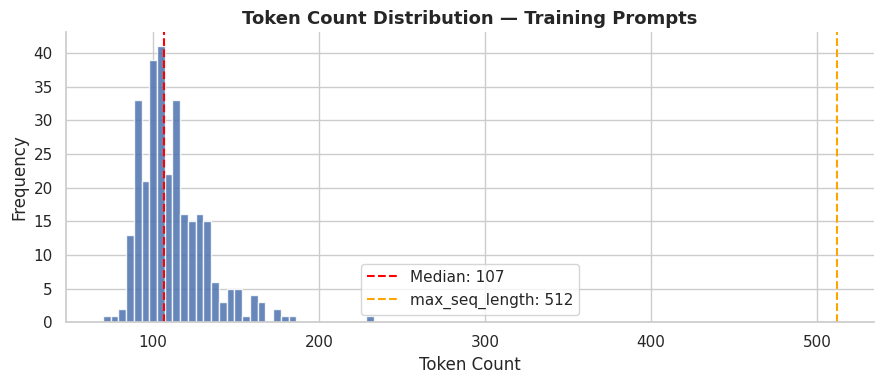

In [12]:
# Analyse actual token counts BEFORE loading the full model
# (tokenizer alone is lightweight)
print("Loading tokenizer for analysis...")
analysis_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
analysis_tokenizer.pad_token = analysis_tokenizer.eos_token

sample_texts = train_df['text'].tolist()[:300]
token_lengths = [
    len(analysis_tokenizer.encode(t, truncation=False))
    for t in sample_texts
]

token_arr = np.array(token_lengths)

#Format
print(f"\nActual token statistics (first 300 training samples):")
print(f"  Mean:   {token_arr.mean():.1f}")
print(f"  Median: {np.median(token_arr):.1f}")
print(f"  Max:    {token_arr.max()}")
print(f"  Min:    {token_arr.min()}")
print(f"  %% within {MAX_SEQ_LENGTH} tokens: {(token_arr <= MAX_SEQ_LENGTH).mean()*100:.1f}%%")


#Graphic info
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(token_arr, bins=35, color='#4C72B0', alpha=0.85, edgecolor='white')
ax.axvline(np.median(token_arr), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {np.median(token_arr):.0f}')
ax.axvline(MAX_SEQ_LENGTH, color='orange', linestyle='--', linewidth=1.5,
           label=f'max_seq_length: {MAX_SEQ_LENGTH}')

#Format
ax.set_title('Token Count Distribution — Training Prompts', fontsize=13, fontweight='bold')
ax.set_xlabel('Token Count')
ax.set_ylabel('Frequency')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('token_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

del analysis_tokenizer

In [13]:
# Convert to HuggingFace Dataset — required by SFTTrainer
train_dataset = Dataset.from_pandas(train_df[['text']])
print(f"HF training dataset: {train_dataset}")

HF training dataset: Dataset({
    features: ['text'],
    num_rows: 1000
})


## 5. Baseline Inference — Before Fine-Tuning

We capture the **base model's outputs on our test set** before any training. This gives us a concrete baseline to compare against the fine-tuned model.

### What is 4-bit Quantization (QLoRA)?

Standard model weights are stored as 16-bit or 32-bit floats. **Quantization** compresses them to 4-bit integers, reducing VRAM usage by ~4×.

We use `BitsAndBytesConfig` with:
- **NF4 (NormalFloat4)**: a quantization format optimized for normally-distributed weights — better quality than standard int4
- **fp16 compute dtype**: dequantize to fp16 for the forward pass, maintaining numerical stability
- **Double quantization**: quantize the quantization constants themselves, saving an extra ~0.37 bits per parameter

In [14]:
# Configure 4-bit quantization using BitsAndBytes to reduce memory usage
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                      # Load model weights in 4-bit precision
    bnb_4bit_quant_type="nf4",              # Use NormalFloat4 (NF4), optimized for LLMs
    bnb_4bit_compute_dtype=torch.float16,   # Use float16 for computation (faster on GPUs)
    bnb_4bit_use_double_quant=True,         # Apply double quantization for extra compression
)


print(f"Loading '{MODEL_NAME}' in 4-bit...")

# Load the base model with quantization and automatic device placement (CPU/GPU)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",  # Automatically distribute model across available hardware
)

# Load the tokenizer associated with the model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Set padding token to EOS token to avoid issues if pad_token is undefined
tokenizer.pad_token = tokenizer.eos_token

# Ensure padding is applied to the right side (important for causal models)
tokenizer.padding_side = "right"

# Count total number of parameters in the model
total_params = sum(p.numel() for p in model.parameters())

# Print summary information
print(f"\nModel loaded.")
print(f"Total parameters: {total_params / 1e6:.0f}M")  # Display in millions

Loading 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' in 4-bit...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model loaded.
Total parameters: 616M


In [15]:
def generate_sql(model, tokenizer, prompt: str, max_new_tokens: int = 128) -> str:
    # Tokenize the input prompt and convert it to PyTorch tensors
    inputs = tokenizer(
        prompt,
        return_tensors="pt",          # Return PyTorch tensors
        truncation=True,              # Truncate if input exceeds max length
        max_length=MAX_SEQ_LENGTH,    # Limit input length to model's context size
    ).to(model.device)               # Move tensors to the same device as the model


    with torch.no_grad():
        # Remove any default max_length constraint from generation config
        model.generation_config.max_length = None

        # Generate output tokens from the model
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,   # Limit number of generated tokens
            do_sample=True,                  # Enable sampling (instead of greedy decoding)
            temperature=0.1,                 # Low temperature → more deterministic output
            top_p=0.9,                       # Nucleus sampling (keep top 90% probability mass)
            pad_token_id=tokenizer.eos_token_id,  # Use EOS as padding token
            eos_token_id=tokenizer.eos_token_id,  # Stop generation at EOS token
            use_cache=False,                 # Disable KV cache (can reduce memory issues)
        )

    # Extract only the newly generated tokens (exclude the input prompt)
    new_tokens = output_ids[0][inputs['input_ids'].shape[1]:]

    # Decode tokens into human-readable text
    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True)

    # Return only the first line (useful if model generates extra text)
    return decoded.split('\n')[0].strip()

In [16]:
N_EVAL = 5   # Number of test examples to compare before/after

print(f"── Baseline inference on {N_EVAL} test examples (BASE model, no fine-tuning) ──\n")

baseline_results = []
for i in range(N_EVAL):
    row = test_df.iloc[i]
    #For each prompt in Eval Dataset, generate the answer using generate_sql
    pred = generate_sql(model, tokenizer, row['prompt'])
    baseline_results.append({
        'question': row['question'],
        'expected': row['answer'],
        'baseline': pred,
    })
    print(f"[{i+1}] Question: {row['question']}")
    print(f"     Expected: {row['answer']}")
    print(f"     Baseline: {pred}")
    print()

── Baseline inference on 5 test examples (BASE model, no fine-tuning) ──

[1] Question: What was the number of Laps with a Grid of more than 3 and Time of 39:24.967?
     Expected: SELECT MIN(laps) FROM table_name_8 WHERE grid > 3 AND time = "39:24.967"
     Baseline: SELECT COUNT(*) FROM table_name_8 WHERE Laps > 3 AND Grid LIKE '%3%' AND Time >= '39:24:00.000'

[2] Question: Which Senior status has a Chief Judge of —, a Reason for termination of death, and Active service of 1967–1983?
     Expected: SELECT senior_status FROM table_name_18 WHERE chief_judge = "—" AND reason_for_termination = "death" AND active_service = "1967–1983"
     Baseline: SELECT * FROM table_name_18 WHERE senior_status = '1967-1983' AND active_service = '1967-1983' AND chief_judge = 'Death' AND reason_for_termination = 'Death'

[3] Question: Which Rank has a Reaction of 0.198, and a Time smaller than 46.3?
     Expected: SELECT MAX(rank) FROM table_name_98 WHERE react = 0.198 AND time < 46.3
     Baseline: SEL

## 6. QLoRA Adapter Configuration

**How LoRA works:**  
Instead of updating all weights $W$ in a layer, LoRA injects two small matrices $A$ and $B$ such that:

$$W' = W + \alpha \cdot (B \cdot A)$$

where $A \in \mathbb{R}^{r \times d_{in}}$ and $B \in \mathbb{R}^{d_{out} \times r}$, and $r \ll d_{in}, d_{out}$ is the **rank**.

Only $A$ and $B$ are trained. $W$ (the original quantized weights) stays frozen.

**Key hyperparameters:**
| Param | Value | Meaning |
|---|---|---|
| `r` | 16 | Rank — higher = more expressiveness, more params |
| `lora_alpha` | 32 | Scaling factor — effectively `alpha/r = 2x` learning rate multiplier |
| `target_modules` | q, k, v, o projections | Which weight matrices to adapt (all attention projections) |
| `lora_dropout` | 0.05 | Regularization on adapter weights |

In [17]:
# Prepare the quantized model for k-bit (e.g., 4-bit) training
# - Enables gradient checkpointing (reduces memory usage)
# - Casts certain layers (like LayerNorm) to fp32 for numerical stability
model = prepare_model_for_kbit_training(model)

# Define LoRA (Low-Rank Adaptation) configuration
lora_config = LoraConfig(
    r=16,                                   # Rank of the low-rank decomposition (controls capacity)
    lora_alpha=32,                           # Scaling factor for LoRA updates
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Apply LoRA to attention projection layers
    lora_dropout=0.05,                       # Dropout applied to LoRA layers (regularization)
    bias="none",                             # Do not train bias parameters
    task_type=TaskType.CAUSAL_LM,             # Task type: causal language modeling
)

# Wrap the base model with PEFT to inject LoRA adapters
model = get_peft_model(model, lora_config)

# Compute parameter statistics
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)  # Parameters that will be updated
total = sum(p.numel() for p in model.parameters())                         # Total parameters in the model
frozen = total - trainable                                                 # Parameters kept frozen

# Print parameter breakdown
print(f"Trainable parameters:  {trainable:>12,}  ({trainable/total*100:.3f}%)")
print(f"Frozen parameters:     {frozen:>12,}  ({frozen/total*100:.3f}%)")
print(f"Total parameters:      {total:>12,}")

# Show efficiency gain compared to full fine-tuning
print(f"\nQLoRA reduces trainable params by {100 - trainable/total*100:.1f}% vs full fine-tuning.")

Trainable parameters:     4,505,600  (0.727%)
Frozen parameters:      615,606,272  (99.273%)
Total parameters:       620,111,872

QLoRA reduces trainable params by 99.3%% vs full fine-tuning.


## 7. Supervised Fine-Tuning

We use `SFTTrainer` from the `trl` library, which wraps HuggingFace `Trainer` with conveniences for causal LM fine-tuning.

**Notable training choices:**
- **Gradient accumulation** (`steps=4`): simulates a batch of 16 without needing 16 samples in VRAM at once
- **Cosine LR scheduler**: smooth decay from peak lr → 0, avoids sharp drops
- **`group_by_length=True`**: batches sequences of similar length together, reducing padding waste and speeding up training by ~10-15%
- **`fp16=True`**: mixed-precision arithmetic for faster matrix ops on T4

In [19]:
sft_config = SFTConfig(
    # ── Output ──────────────────────────────────────────────────
    output_dir=ADAPTER_SAVE_PATH,

    # ── Duration ─────────────────────────────────────────────────
    num_train_epochs=3,

    # ── Batching ─────────────────────────────────────────────────
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # Effective batch = 4 × 4 = 16

    # ── Optimizer ────────────────────────────────────────────────
    learning_rate=2e-4,
    weight_decay=0.001,
    warmup_steps=50,
    lr_scheduler_type="cosine",

    # ── Precision ────────────────────────────────────────────────
    fp16=False,
    bf16=True,                       # matches TinyLlama's native bfloat16

    # ── Sequence & Dataset ───────────────────────────────────────
    max_length=MAX_SEQ_LENGTH,       # max_seq_length renamed to max_length
    dataset_text_field="text",

    # ── Logging & Saving ─────────────────────────────────────────
    logging_steps=10,
    save_strategy="epoch",

    # ── Misc ─────────────────────────────────────────────────────
    report_to="none",
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

steps_per_epoch = len(train_dataset) // (sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps)
print("=== Training Configuration ===")
print(f"  Samples:          {len(train_dataset):,}")
print(f"  Epochs:           {sft_config.num_train_epochs}")
print(f"  Batch size:       {sft_config.per_device_train_batch_size} × {sft_config.gradient_accumulation_steps} (grad. accum.)")
print(f"  Steps/epoch:      ~{steps_per_epoch}")
print(f"  Total steps:      ~{steps_per_epoch * int(sft_config.num_train_epochs)}")
print(f"  Learning rate:    {sft_config.learning_rate}")
print(f"  LR scheduler:     {sft_config.lr_scheduler_type}")

Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

=== Training Configuration ===
  Samples:          1,000
  Epochs:           3
  Batch size:       4 × 4 (grad. accum.)
  Steps/epoch:      ~62
  Total steps:      ~186
  Learning rate:    0.0002
  LR scheduler:     SchedulerType.COSINE


In [20]:
print("Starting fine-tuning...\n")
train_result = trainer.train()

print("\n=== Training Summary ===")
print(f"  Training loss (final):  {train_result.training_loss:.4f}")
print(f"  Total steps:            {train_result.global_step}")
print(f"  Runtime:                {train_result.metrics.get('train_runtime', 0) / 60:.1f} min")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting fine-tuning...



Step,Training Loss
10,2.183113
20,1.913990
30,1.311021
40,0.927044
50,0.811251
60,0.741377
70,0.689874
80,0.653566
90,0.668445
100,0.659133



=== Training Summary ===
  Training loss (final):  0.8500
  Total steps:            189
  Runtime:                22.7 min


## 8. Training Loss Analysis

A steadily decreasing loss confirms the model is learning the SQL generation pattern. If the curve plateaus or diverges, the learning rate or number of epochs would need tuning.

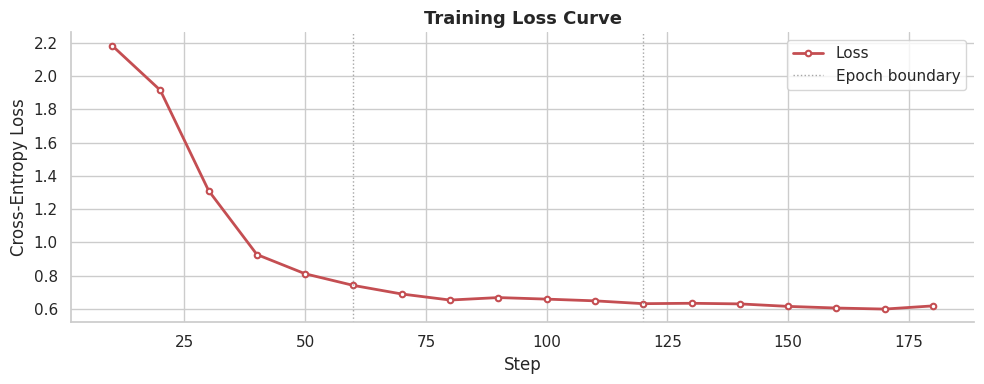

Initial loss: 2.1831
Final loss:   0.6185
Reduction:    71.7%%


In [21]:
#Generate Loss across time graphic

log_history = trainer.state.log_history
loss_logs = [(x['step'], x['loss']) for x in log_history if 'loss' in x]

if loss_logs:
    steps, losses = zip(*loss_logs)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps, losses, color='#C44E52', linewidth=2,
            marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.5)

    # Epoch boundaries
    total_steps = steps[-1]
    steps_per_epoch_approx = total_steps // sft_config.num_train_epochs
    for epoch in range(1, sft_config.num_train_epochs):
        ax.axvline(epoch * steps_per_epoch_approx, color='grey',
                   linestyle=':', linewidth=1, alpha=0.7,
                   label=f'Epoch {epoch}' if epoch == 1 else '')

    ax.set_title('Training Loss Curve', fontsize=13, fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(['Loss', 'Epoch boundary'])
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Initial loss: {losses[0]:.4f}")
    print(f"Final loss:   {losses[-1]:.4f}")
    print(f"Reduction:    {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%%")

## 9. Before vs. After Comparison

We now run the **fine-tuned model** on the same test examples we used for the baseline and compare side by side.

In [22]:
print(f"Running fine-tuned model on {N_EVAL} test examples...\n")

finetuned_preds = []
for i in range(N_EVAL):
    pred = generate_sql(model, tokenizer, test_df.iloc[i]['prompt'])
    finetuned_preds.append(pred)

SEP = '─' * 88
print(f"{' BEFORE vs. AFTER FINE-TUNING ':─^88}\n")

for i, (result, ft_pred) in enumerate(zip(baseline_results, finetuned_preds)):
    print(f"Example {i+1}")
    print(f"  Question : {result['question']}")
    print(f"  Expected : {result['expected']}")
    print(f"  Before   : {result['baseline']}")
    print(f"  After    : {ft_pred}")
    print(SEP)

Running fine-tuned model on 5 test examples...



In [24]:
#Evaluation
# Simple exact-match accuracy on the N_EVAL examples
# (Normalise whitespace and case for a fair comparison)
def normalise(sql: str) -> str:
    return ' '.join(sql.lower().split())

baseline_em = sum(
    normalise(r['baseline']) == normalise(r['expected'])
    for r in baseline_results
)
finetuned_em = sum(
    normalise(p) == normalise(r['expected'])
    for p, r in zip(finetuned_preds, baseline_results)
)

print(f"Exact-match accuracy on {N_EVAL} examples:")
print(f"  Base model (before):  {baseline_em}/{N_EVAL} ({baseline_em/N_EVAL*100:.0f}%)")
print(f"  Fine-tuned (after):   {finetuned_em}/{N_EVAL} ({finetuned_em/N_EVAL*100:.0f}%)")
print()
print("Note: exact-match is a strict metric. Real evaluation uses execution accuracy")
print("(whether the SQL returns the correct rows) — a better signal for Text-to-SQL.")

Exact-match accuracy on 5 examples:
  Base model (before):  0/5 (0%)
  Fine-tuned (after):   2/5 (40%)

Note: exact-match is a strict metric. Real evaluation uses execution accuracy
(whether the SQL returns the correct rows) — a better signal for Text-to-SQL.


## 10. Saving the LoRA Adapter

QLoRA only saves the **adapter weights** — not the full model. The adapter is ~20 MB vs ~2.2 GB for the full model. To use the fine-tuned model later, you load the base model and merge the adapter on top.

In [25]:
model.save_pretrained(ADAPTER_SAVE_PATH)
tokenizer.save_pretrained(ADAPTER_SAVE_PATH)

adapter_size_mb = sum(
    os.path.getsize(os.path.join(ADAPTER_SAVE_PATH, f))
    for f in os.listdir(ADAPTER_SAVE_PATH)
    if os.path.isfile(os.path.join(ADAPTER_SAVE_PATH, f))
) / 1e6

print(f"Adapter saved to: {ADAPTER_SAVE_PATH}")
print(f"Adapter size:     {adapter_size_mb:.1f} MB")
print("\nFiles saved:")
for f in sorted(os.listdir(ADAPTER_SAVE_PATH)):
    size = os.path.getsize(os.path.join(ADAPTER_SAVE_PATH, f)) / 1e6
    print(f"  {f:<40} {size:.2f} MB")

Adapter saved to: ./tinyllama-sql-adapter
Adapter size:     12.7 MB

Files saved:
  README.md                                0.00 MB
  adapter_config.json                      0.00 MB
  adapter_model.safetensors                9.03 MB
  chat_template.jinja                      0.00 MB
  checkpoint-126                           0.00 MB
  checkpoint-189                           0.00 MB
  checkpoint-63                            0.00 MB
  tokenizer.json                           3.62 MB
  tokenizer_config.json                    0.00 MB


## 11. Pushing the Adapter to HuggingFace Hub

The LoRA adapter was published to the HuggingFace Hub and is publicly available.

| Field            | Value                                                                 |
|------------------|-----------------------------------------------------------------------|
| **Repository**   | https://huggingface.co/PieroAguinaga/tinyllama-sql-qlora              |
| **Base model**   | TinyLlama/TinyLlama-1.1B-Chat-v1.0                                    |
| **Adapter size** | ~9 MB (vs ~2.2 GB full model)                                         |
| **Training data**| 1,000 samples — b-mc2/sql-create-context                              |

To reload the fine-tuned model from the Hub in any environment:

```python
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quantization_config=bnb_config,
    device_map="auto",
)

model = PeftModel.from_pretrained(
    base,
    "PieroAguinaga/tinyllama-sql-qlora"
)

tokenizer = AutoTokenizer.from_pretrained(
    "PieroAguinaga/tinyllama-sql-qlora"
)